# Pengujian FFNN - Global Student Placement and Salary

## 1) Import


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torchlike.functional as F
from torchlike import ArrayDataset, DataLoader, Tensor, nn, optim

np.random.seed(123)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#D0D7DE",
        "axes.labelcolor": "#243B53",
        "axes.titleweight": "bold",
        "axes.titlesize": 12,
        "axes.labelsize": 10.5,
        "xtick.color": "#243B53",
        "ytick.color": "#243B53",
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.edgecolor": "#D0D7DE",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
    }
)

FIG_DIR = Path("doc/figures")
if not FIG_DIR.parent.exists():
    FIG_DIR = Path("../doc/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("figures will be saved to:", FIG_DIR.resolve())

PALETTE = [
    "#0F4C5C",
    "#E07A5F",
    "#3D405B",
    "#81B29A",
    "#E09F3E",
    "#C8553D",
    "#6C757D",
]
GRID_COLOR = "#D9E2EC"
TEXT_COLOR = "#243B53"


def paper_axes(nrows=1, ncols=2, figsize=(12.5, 4.6), sharex=False, sharey=False):
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)
    if nrows * ncols == 1:
        axes = axes.reshape(1, 1)
    else:
        axes = axes.reshape(nrows, ncols)
    return fig, axes


def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, loc="left", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, color=GRID_COLOR, linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D7DE")
    ax.spines["bottom"].set_color("#D0D7DE")


def save_figure(fig, filename):
    fig.savefig(FIG_DIR / filename, dpi=220)
    plt.show()


def plot_loss_panel(ax, results, label_fn, title, curve_key="val_curve", train_key=None):
    for idx, result in enumerate(results):
        color = PALETTE[idx % len(PALETTE)]
        if train_key is not None and train_key in result:
            ax.plot(
                result[train_key],
                linestyle="--",
                linewidth=1.4,
                alpha=0.45,
                color=color,
            )
        curve = np.asarray(result[curve_key], dtype=float)
        epochs = np.arange(1, len(curve) + 1)
        ax.plot(epochs, curve, linewidth=2.2, color=color, label=label_fn(result))
        ax.scatter(epochs[-1], curve[-1], s=34, color=color, zorder=3)
    style_axis(ax, title=title, xlabel="Epoch", ylabel="Validation Loss")
    ax.legend(loc="upper right", fontsize=8.8)


def plot_tradeoff_panel(ax, results, label_fn, title, x_key="val_loss", y_key="val_acc", order_key=None):
    if order_key is not None:
        ordered = sorted(results, key=lambda r: r[order_key])
        ax.plot(
            [r[x_key] for r in ordered],
            [r[y_key] for r in ordered],
            color="#BCCCDC",
            linewidth=1.5,
            zorder=1,
        )
    for idx, result in enumerate(results):
        color = PALETTE[idx % len(PALETTE)]
        x_val = float(result[x_key])
        y_val = float(result[y_key])
        ax.scatter(
            x_val,
            y_val,
            s=88,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )
        ax.annotate(
            label_fn(result),
            (x_val, y_val),
            xytext=(6, 7),
            textcoords="offset points",
            fontsize=8.8,
            color=TEXT_COLOR,
        )
    style_axis(ax, title=title, xlabel="Validation Loss", ylabel="Validation Accuracy")
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.yaxis.set_major_locator(MaxNLocator(5))


def plot_distribution_panel(ax, results, dist_key, label_fn, title, xlabel):
    arrays = [np.asarray(r[dist_key], dtype=float) for r in results if len(r[dist_key])]
    if arrays:
        combined = np.concatenate(arrays)
        lo, hi = np.quantile(combined, [0.01, 0.99])
        span = max(hi - lo, 1e-6)
        ax.set_xlim(lo - 0.08 * span, hi + 0.08 * span)
    for idx, result in enumerate(results):
        values = np.asarray(result[dist_key], dtype=float)
        color = PALETTE[idx % len(PALETTE)]
        ax.hist(
            values,
            bins=48,
            density=True,
            histtype="step",
            linewidth=2.0,
            color=color,
            label=label_fn(result),
        )
    ax.axvline(0.0, color="#7B8794", linewidth=1.0, linestyle=":")
    style_axis(ax, title=title, xlabel=xlabel, ylabel="Density")
    ax.legend(loc="upper right", fontsize=8.5)



figures will be saved to: /Users/ellipsis/Documents/TorchIsAllYouNeed/doc/figures


## 2) Load Dataset + Preprocessing


In [3]:
paths = [
    Path("data/datasetml_2026.csv"),
    Path("../data/datasetml_2026.csv"),
    Path("datasetml_2026.csv"),
]

existing = [p for p in paths if p.exists()]
if len(existing) == 0:
    raise FileNotFoundError("datasetml_2026.csv tidak ditemukan")

csv_path = existing[0]
print("dataset:", csv_path)

df = pd.read_csv(csv_path)
print("shape:", df.shape)
df.head()

dataset: ../data/datasetml_2026.csv
shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
target_col = "placement_status"
num_cols = [
    "cgpa",
    "backlogs",
    "internship_count",
    "aptitude_score",
    "communication_score",
    "internship_quality_score",
]
cat_cols = [
    "college_tier",
    "country",
    "university_ranking_band",
    "specialization",
    "industry",
]

y = (df[target_col] == "Placed").astype(int).values
X = df.drop(columns=[target_col]).copy()

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123,
    shuffle=True,
    stratify=y,
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop",
)

X_train = preprocess.fit_transform(X_train_df).astype(np.float64)
X_val = preprocess.transform(X_val_df).astype(np.float64)
y_train_col = y_train.reshape(-1, 1).astype(np.float64)
y_val_col = y_val.reshape(-1, 1).astype(np.float64)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("positive rate train:", y_train.mean())
print("positive rate val  :", y_val.mean())

X_train: (8000, 28)
X_val  : (2000, 28)
positive rate train: 0.61525
positive rate val  : 0.6155


## 3) Pengaruh Depth dan Width


In [5]:
width_values = [8, 16, 24, 32]
width_results = []

for w in width_values:
    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], w, init="he", seed=7),
            nn.GELU(),
            nn.Linear(w, w, init="he", seed=11),
            nn.SELU(),
            nn.Linear(w, w, init="he", seed=13),
            nn.GELU(),
            nn.Linear(w, 1, init="he", seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []

    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_logits = model(Tensor(X_train))
        val_logits = model(Tensor(X_val))
        train_loss = criterion(train_logits, Tensor(y_train_col)).item()
        val_loss = criterion(val_logits, Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    width_results.append(
        {
            "width": w,
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
        }
    )

pd.DataFrame(
    [
        {"width": r["width"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in width_results
    ]
).sort_values("width")

,width,val_acc,val_loss
0,8,0.7480,0.487501
1,16,0.7550,0.496688
2,24,0.7490,0.495326
3,32,0.7395,0.499106


In [6]:
depth_values = [2, 3, 4]
depth_results = []

for d in depth_values:
    layers = []
    in_dim = X_train.shape[1]
    for i in range(d):
        layers.append(nn.Linear(in_dim, 32, init="he", seed=7 + i * 2))
        if i % 2 == 0:
            layers.append(nn.GELU())
        else:
            layers.append(nn.SELU())
        in_dim = 32
    layers.append(nn.Linear(in_dim, 1, init="he", seed=77))

    model = nn.Sequential(layers)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []

    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_logits = model(Tensor(X_train))
        val_logits = model(Tensor(X_val))
        train_loss = criterion(train_logits, Tensor(y_train_col)).item()
        val_loss = criterion(val_logits, Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    depth_results.append(
        {
            "depth": d,
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
        }
    )

pd.DataFrame(
    [
        {"depth": r["depth"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in depth_results
    ]
).sort_values("depth")

,depth,val_acc,val_loss
0,2,0.7495,0.490592
1,3,0.7545,0.494330
2,4,0.7470,0.501000


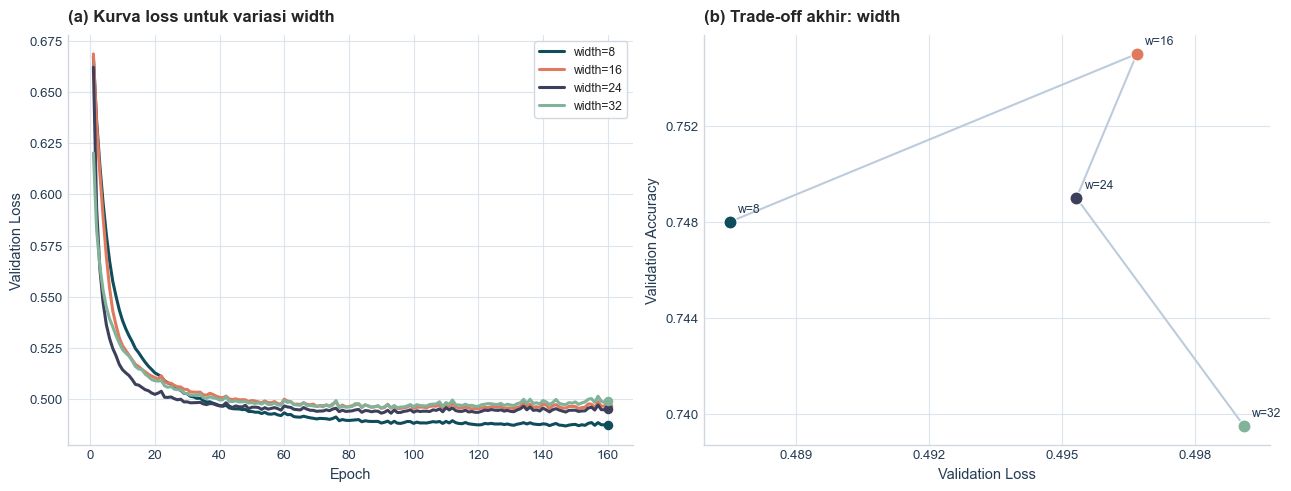

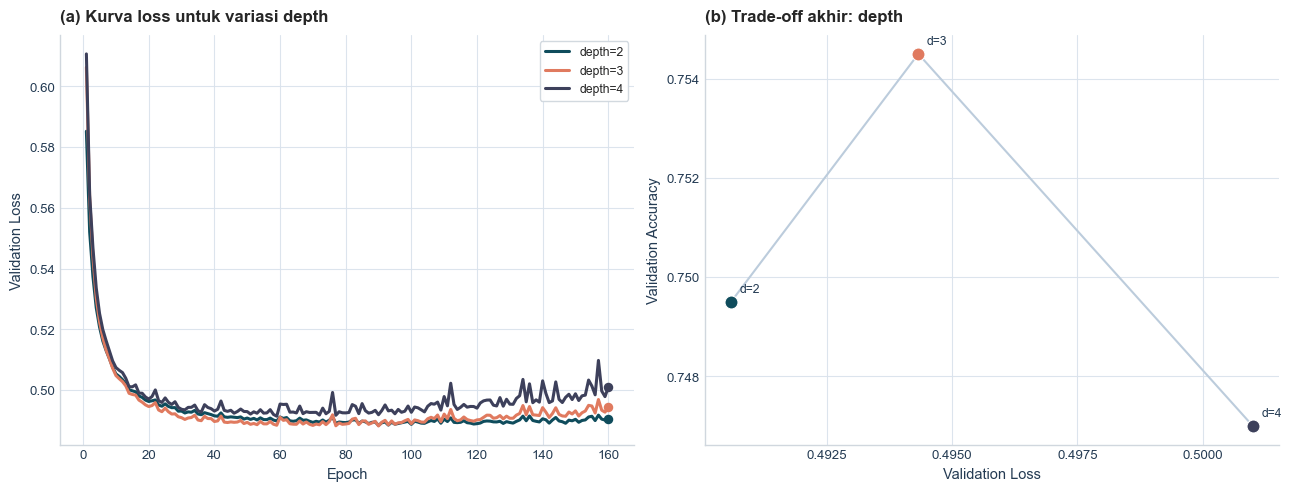

In [7]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    width_results,
    label_fn=lambda r: f"width={r['width']}",
    title="(a) Kurva loss untuk variasi width",
)
plot_tradeoff_panel(
    axes[0, 1],
    width_results,
    label_fn=lambda r: f"w={r['width']}",
    title="(b) Trade-off akhir: width",
    order_key="width",
)
save_figure(fig, "depth_width_width_loss.png")

fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    depth_results,
    label_fn=lambda r: f"depth={r['depth']}",
    title="(a) Kurva loss untuk variasi depth",
)
plot_tradeoff_panel(
    axes[0, 1],
    depth_results,
    label_fn=lambda r: f"d={r['depth']}",
    title="(b) Trade-off akhir: depth",
    order_key="depth",
)
save_figure(fig, "depth_width_depth_loss.png")



## 4) Pengaruh Fungsi Aktivasi


In [8]:
activation_names = ["relu", "sigmoid", "tanh", "gelu", "selu"]
activation_results = []

for act in activation_names:
    if act == "relu":
        a1, a2, a3 = nn.ReLU(), nn.ReLU(), nn.ReLU()
    elif act == "sigmoid":
        a1, a2, a3 = nn.Sigmoid(), nn.Sigmoid(), nn.Sigmoid()
    elif act == "tanh":
        a1, a2, a3 = nn.Tanh(), nn.Tanh(), nn.Tanh()
    elif act == "gelu":
        a1, a2, a3 = nn.GELU(), nn.GELU(), nn.GELU()
    else:
        a1, a2, a3 = nn.SELU(), nn.SELU(), nn.SELU()

    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], 32, init="he", seed=7),
            a1,
            nn.Linear(32, 32, init="he", seed=11),
            a2,
            nn.Linear(32, 32, init="he", seed=13),
            a3,
            nn.Linear(32, 1, init="he", seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_logits = model(Tensor(X_val))
        val_loss = criterion(val_logits, Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    for p in model.parameters():
        p.zero_grad()
    full_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col))
    full_loss.backward()

    weight_dist = np.concatenate(
        [p.data.reshape(-1) for p in model.parameters() if p.data.ndim >= 2]
    )
    grad_dist = np.concatenate(
        [
            p.grad.reshape(-1)
            for p in model.parameters()
            if p.grad is not None and p.grad.ndim >= 2
        ]
    )

    activation_results.append(
        {
            "activation": act,
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
            "weight_dist": weight_dist,
            "grad_dist": grad_dist,
        }
    )

pd.DataFrame(
    [
        {
            "activation": r["activation"],
            "val_acc": r["val_acc"],
            "val_loss": r["val_loss"],
        }
        for r in activation_results
    ]
).sort_values("val_acc", ascending=False)

,activation,val_acc,val_loss
0,relu,0.7545,0.496800
1,sigmoid,0.7485,0.495661
4,selu,0.7470,0.501312
2,tanh,0.7465,0.496457
3,gelu,0.7460,0.489987


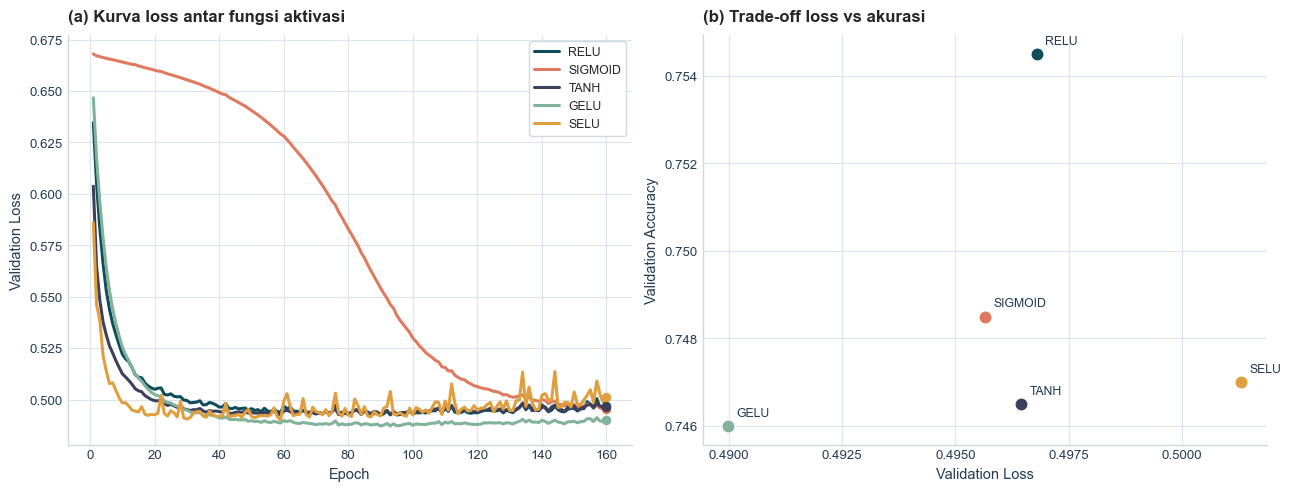

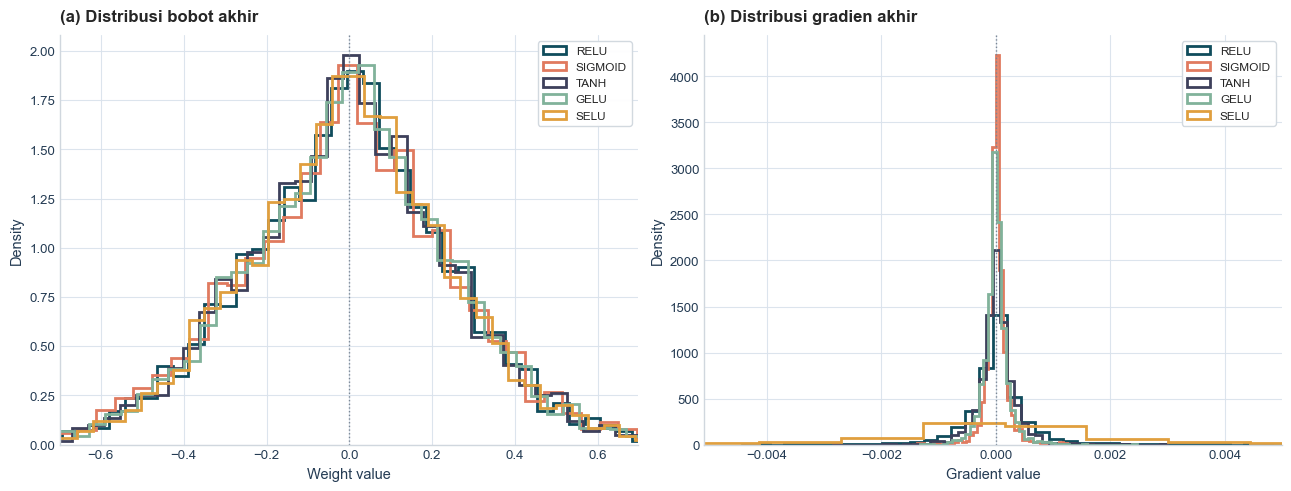

In [9]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    activation_results,
    label_fn=lambda r: r["activation"].upper(),
    title="(a) Kurva loss antar fungsi aktivasi",
)
plot_tradeoff_panel(
    axes[0, 1],
    activation_results,
    label_fn=lambda r: r["activation"].upper(),
    title="(b) Trade-off loss vs akurasi",
)
save_figure(fig, "activation_loss.png")

fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_distribution_panel(
    axes[0, 0],
    activation_results,
    dist_key="weight_dist",
    label_fn=lambda r: r["activation"].upper(),
    title="(a) Distribusi bobot akhir",
    xlabel="Weight value",
)
plot_distribution_panel(
    axes[0, 1],
    activation_results,
    dist_key="grad_dist",
    label_fn=lambda r: r["activation"].upper(),
    title="(b) Distribusi gradien akhir",
    xlabel="Gradient value",
)
save_figure(fig, "activation_distribution.png")



## 5) Pengaruh Learning Rate


In [10]:
lr_values = [0.1, 0.03, 0.005]
lr_results = []

for lr in lr_values:
    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], 32, init="he", seed=7),
            nn.GELU(),
            nn.Linear(32, 32, init="he", seed=11),
            nn.SELU(),
            nn.Linear(32, 32, init="he", seed=13),
            nn.GELU(),
            nn.Linear(32, 1, init="he", seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_loss = criterion(model(Tensor(X_val)), Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    for p in model.parameters():
        p.zero_grad()
    full_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col))
    full_loss.backward()

    weight_dist = np.concatenate(
        [p.data.reshape(-1) for p in model.parameters() if p.data.ndim >= 2]
    )
    grad_dist = np.concatenate(
        [
            p.grad.reshape(-1)
            for p in model.parameters()
            if p.grad is not None and p.grad.ndim >= 2
        ]
    )

    lr_results.append(
        {
            "lr": lr,
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
            "weight_dist": weight_dist,
            "grad_dist": grad_dist,
        }
    )

pd.DataFrame(
    [
        {"lr": r["lr"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in lr_results
    ]
).sort_values("lr")

,lr,val_acc,val_loss
2,0.005,0.7410,0.504540
1,0.030,0.7395,0.499106
0,0.100,0.7350,0.548050


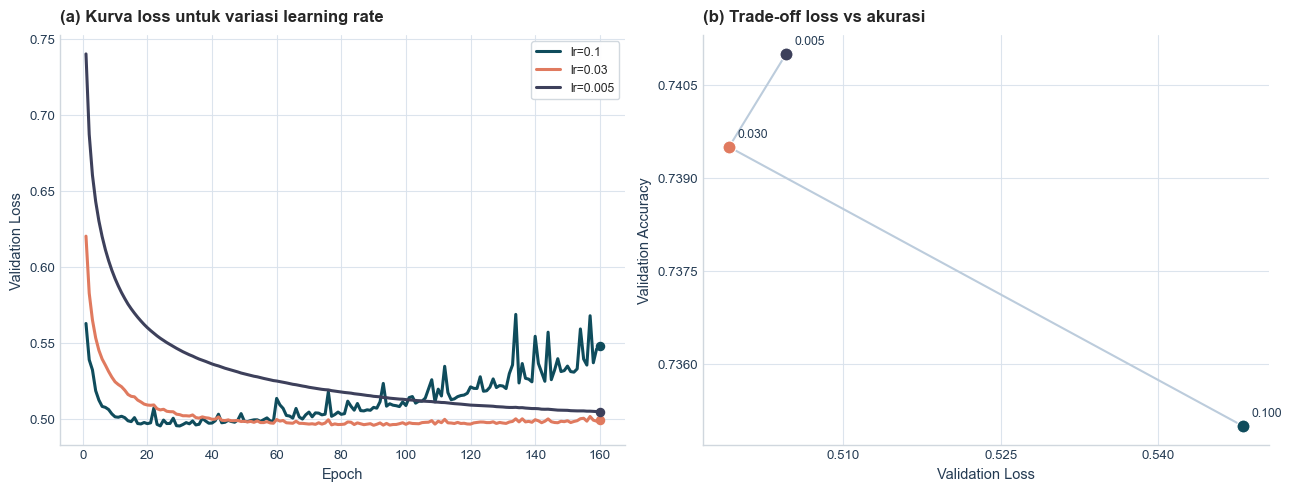

In [11]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    lr_results,
    label_fn=lambda r: f"lr={r['lr']}",
    title="(a) Kurva loss untuk variasi learning rate",
)
plot_tradeoff_panel(
    axes[0, 1],
    lr_results,
    label_fn=lambda r: f"{r['lr']:.3f}",
    title="(b) Trade-off loss vs akurasi",
    order_key="lr",
)
save_figure(fig, "learning_rate_loss.png")



## 6) Pengaruh Inisialisasi Bobot


In [12]:
# Zero dipakai sebagai kontrol negatif untuk menguji kegagalan symmetry breaking.
init_values = ["zero", "xavier", "he"]
init_results = []

for init_name in init_values:
    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], 32, init=init_name, seed=7),
            nn.GELU(),
            nn.Linear(32, 32, init=init_name, seed=11),
            nn.SELU(),
            nn.Linear(32, 32, init=init_name, seed=13),
            nn.GELU(),
            nn.Linear(32, 1, init=init_name, seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_loss = criterion(model(Tensor(X_val)), Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    init_results.append(
        {
            "init": init_name,
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
        }
    )

pd.DataFrame(
    [
        {"init": r["init"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in init_results
    ]
)

,init,val_acc,val_loss
0,zero,0.6155,0.666224
1,xavier,0.7520,0.487765
2,he,0.7395,0.499106


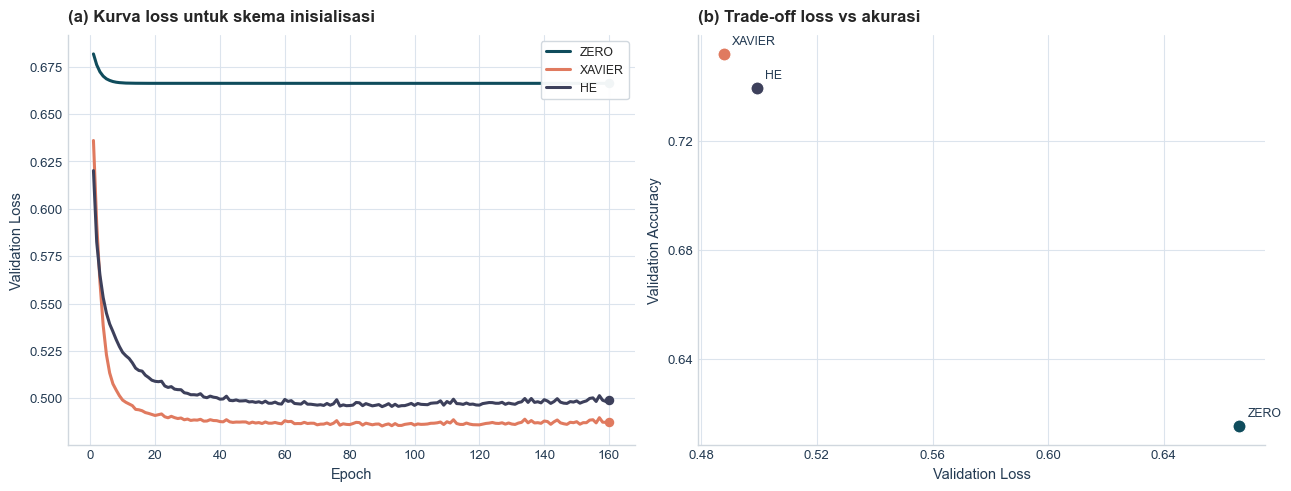

In [13]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    init_results,
    label_fn=lambda r: r["init"].upper(),
    title="(a) Kurva loss untuk skema inisialisasi",
)
plot_tradeoff_panel(
    axes[0, 1],
    init_results,
    label_fn=lambda r: r["init"].upper(),
    title="(b) Trade-off loss vs akurasi",
)
save_figure(fig, "initialization_loss.png")



## 7) Pengaruh Regularisasi


In [14]:
reg_settings = [
    {"name": "NoReg", "l1": 0.0, "l2": 0.0},
    {"name": "L1", "l1": 1e-5, "l2": 0.0},
    {"name": "L2", "l1": 0.0, "l2": 1e-4},
]
reg_results = []

for cfg in reg_settings:
    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], 32, init="he", seed=7),
            nn.GELU(),
            nn.Linear(32, 32, init="he", seed=11),
            nn.SELU(),
            nn.Linear(32, 32, init="he", seed=13),
            nn.GELU(),
            nn.Linear(32, 1, init="he", seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=0.03,
        l1_lambda=cfg["l1"],
        l2_lambda=cfg["l2"],
    )
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_loss = criterion(model(Tensor(X_val)), Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    for p in model.parameters():
        p.zero_grad()
    full_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col))
    full_loss.backward()

    weight_dist = np.concatenate(
        [p.data.reshape(-1) for p in model.parameters() if p.data.ndim >= 2]
    )
    grad_dist = np.concatenate(
        [
            p.grad.reshape(-1)
            for p in model.parameters()
            if p.grad is not None and p.grad.ndim >= 2
        ]
    )

    reg_results.append(
        {
            "setting": cfg["name"],
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "train_curve": train_curve,
            "val_curve": val_curve,
            "weight_dist": weight_dist,
            "grad_dist": grad_dist,
        }
    )

pd.DataFrame(
    [
        {"setting": r["setting"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in reg_results
    ]
)

,setting,val_acc,val_loss
0,NoReg,0.7400,0.499616
1,L1,0.7400,0.499428
2,L2,0.7395,0.499106


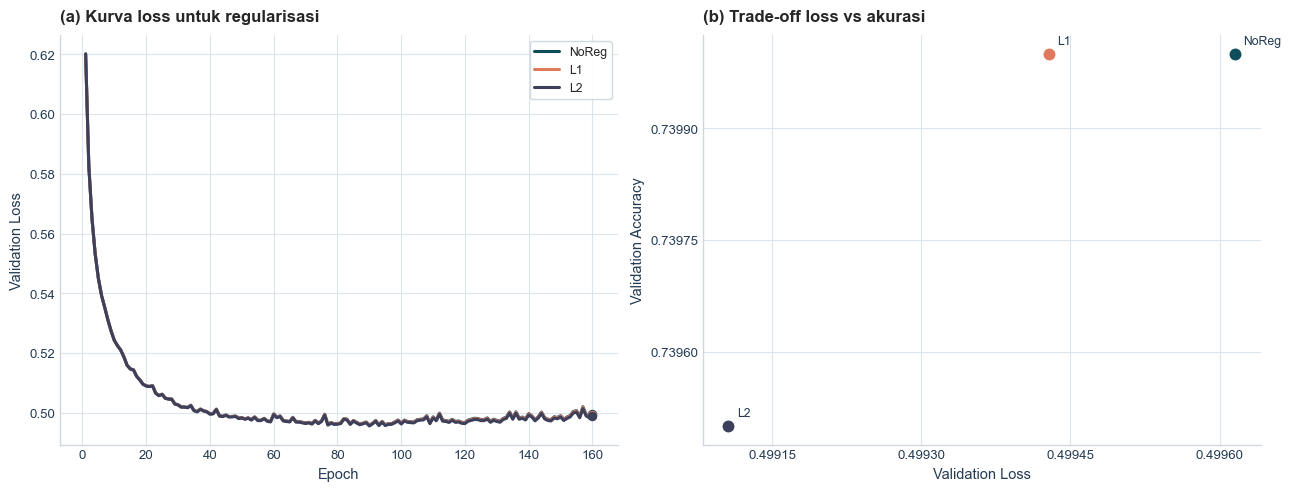

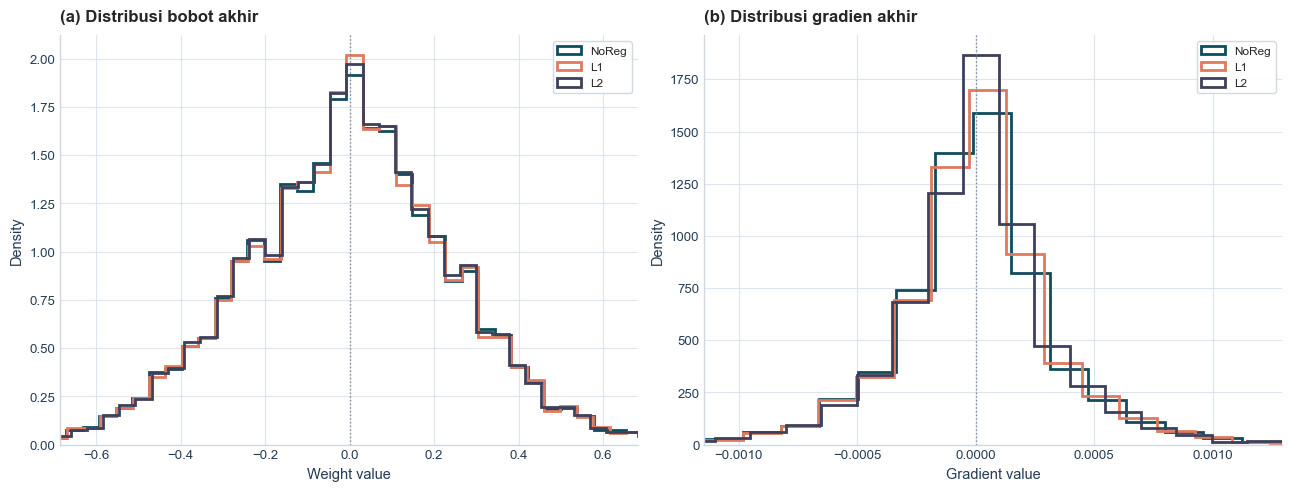

In [15]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    reg_results,
    label_fn=lambda r: r["setting"],
    title="(a) Kurva loss untuk regularisasi",
)
plot_tradeoff_panel(
    axes[0, 1],
    reg_results,
    label_fn=lambda r: r["setting"],
    title="(b) Trade-off loss vs akurasi",
)
save_figure(fig, "regularization_loss.png")

fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_distribution_panel(
    axes[0, 0],
    reg_results,
    dist_key="weight_dist",
    label_fn=lambda r: r["setting"],
    title="(a) Distribusi bobot akhir",
    xlabel="Weight value",
)
plot_distribution_panel(
    axes[0, 1],
    reg_results,
    dist_key="grad_dist",
    label_fn=lambda r: r["setting"],
    title="(b) Distribusi gradien akhir",
    xlabel="Gradient value",
)
save_figure(fig, "regularization_distribution.png")



## 8) Pengaruh RMSNorm


In [16]:
rms_results = []

for use_norm in [False, True]:
    layers = [nn.Linear(X_train.shape[1], 32, init="he", seed=7)]
    if use_norm:
        layers.append(nn.RMSNorm(32))
    layers.append(nn.GELU())

    layers.append(nn.Linear(32, 32, init="he", seed=11))
    if use_norm:
        layers.append(nn.RMSNorm(32))
    layers.append(nn.SELU())

    layers.append(nn.Linear(32, 32, init="he", seed=13))
    if use_norm:
        layers.append(nn.RMSNorm(32))
    layers.append(nn.GELU())

    layers.append(nn.Linear(32, 1, init="he", seed=17))

    model = nn.Sequential(layers)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_loss = criterion(model(Tensor(X_val)), Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    for p in model.parameters():
        p.zero_grad()
    full_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col))
    full_loss.backward()

    weight_dist = np.concatenate(
        [p.data.reshape(-1) for p in model.parameters() if p.data.ndim >= 2]
    )
    grad_dist = np.concatenate(
        [
            p.grad.reshape(-1)
            for p in model.parameters()
            if p.grad is not None and p.grad.ndim >= 2
        ]
    )

    rms_results.append(
        {
            "name": "RMSNorm" if use_norm else "NoNorm",
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "pred": val_pred,
            "train_curve": train_curve,
            "val_curve": val_curve,
            "weight_dist": weight_dist,
            "grad_dist": grad_dist,
        }
    )

pd.DataFrame(
    [
        {"model": r["name"], "val_acc": r["val_acc"], "val_loss": r["val_loss"]}
        for r in rms_results
    ]
)

,model,val_acc,val_loss
0,NoNorm,0.7395,0.499106
1,RMSNorm,0.7480,0.508377


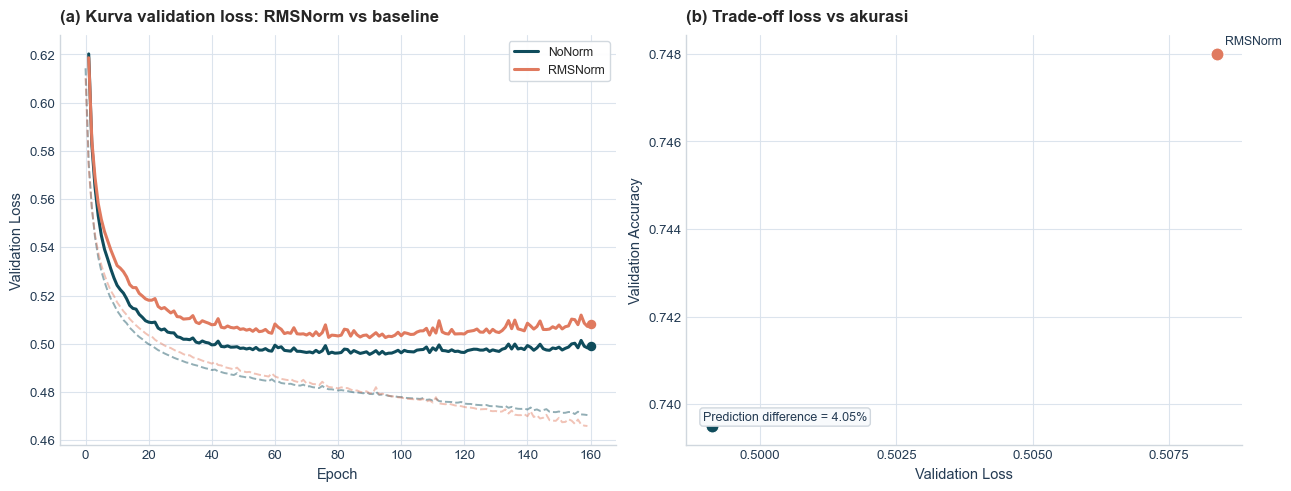

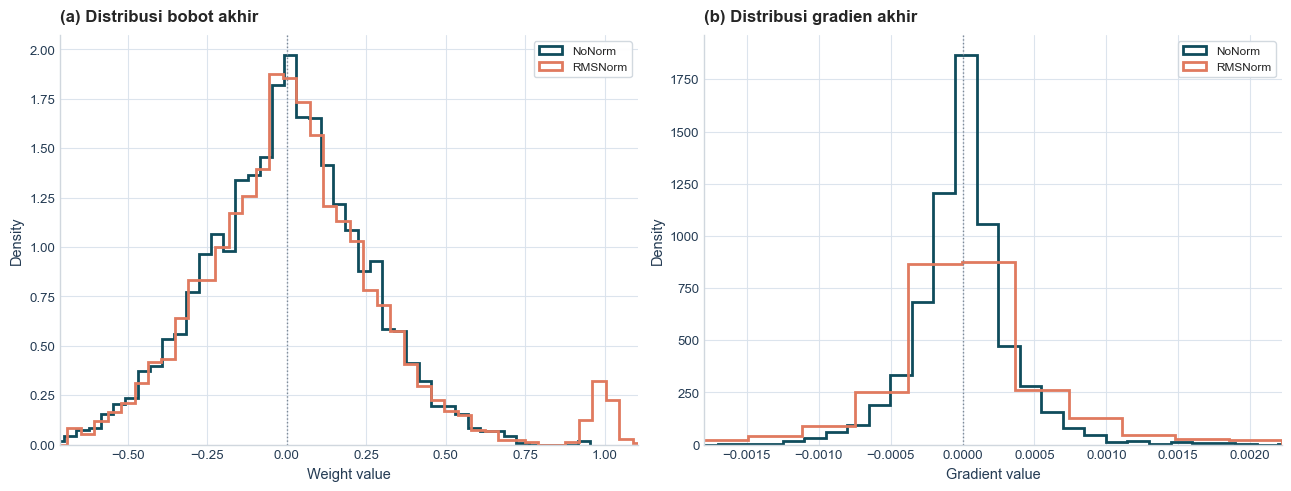

prediction difference (NoNorm vs RMSNorm): 0.0405


In [17]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    rms_results,
    label_fn=lambda r: r["name"],
    title="(a) Kurva validation loss: RMSNorm vs baseline",
    train_key="train_curve",
)
plot_tradeoff_panel(
    axes[0, 1],
    rms_results,
    label_fn=lambda r: r["name"],
    title="(b) Trade-off loss vs akurasi",
)
pred_diff = np.mean(rms_results[0]["pred"] != rms_results[1]["pred"])
axes[0, 1].text(
    0.03,
    0.06,
    f"Prediction difference = {pred_diff:.2%}",
    transform=axes[0, 1].transAxes,
    fontsize=9,
    color=TEXT_COLOR,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="#F8FAFC", edgecolor="#D0D7DE"),
)
save_figure(fig, "rmsnorm_loss.png")

fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_distribution_panel(
    axes[0, 0],
    rms_results,
    dist_key="weight_dist",
    label_fn=lambda r: r["name"],
    title="(a) Distribusi bobot akhir",
    xlabel="Weight value",
)
plot_distribution_panel(
    axes[0, 1],
    rms_results,
    dist_key="grad_dist",
    label_fn=lambda r: r["name"],
    title="(b) Distribusi gradien akhir",
    xlabel="Gradient value",
)
save_figure(fig, "rmsnorm_distribution.png")

print("prediction difference (NoNorm vs RMSNorm):", float(pred_diff))



## 9) SGD vs Adam


In [18]:
opt_results = []

for opt_name in ["sgd", "adam"]:
    model = nn.Sequential(
        [
            nn.Linear(X_train.shape[1], 32, init="he", seed=7),
            nn.GELU(),
            nn.Linear(32, 32, init="he", seed=11),
            nn.SELU(),
            nn.Linear(32, 32, init="he", seed=13),
            nn.GELU(),
            nn.Linear(32, 1, init="he", seed=17),
        ]
    )

    criterion = nn.BCEWithLogitsLoss()
    if opt_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=2e-4, l2_lambda=1e-4)

    loader = DataLoader(
        ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
    )

    train_curve = []
    val_curve = []
    for epoch in range(160):
        for xb, yb in loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = criterion(model(Tensor(X_train)), Tensor(y_train_col)).item()
        val_loss = criterion(model(Tensor(X_val)), Tensor(y_val_col)).item()
        train_curve.append(train_loss)
        val_curve.append(val_loss)

    val_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
    val_pred = (val_prob >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, val_pred)

    opt_results.append(
        {
            "optimizer": opt_name.upper(),
            "val_acc": float(val_acc),
            "val_loss": float(val_curve[-1]),
            "best_val_loss": float(np.min(val_curve)),
            "best_epoch": int(np.argmin(val_curve) + 1),
            "val_curve": val_curve,
        }
    )

pd.DataFrame(
    [
        {
            "optimizer": r["optimizer"],
            "val_acc": r["val_acc"],
            "val_loss": r["val_loss"],
            "best_val_loss": r["best_val_loss"],
            "best_epoch": r["best_epoch"],
        }
        for r in opt_results
    ]
)

,optimizer,val_acc,val_loss,best_val_loss,best_epoch
0,SGD,0.7395,0.499106,0.495614,90
1,ADAM,0.7400,0.501102,0.492404,64


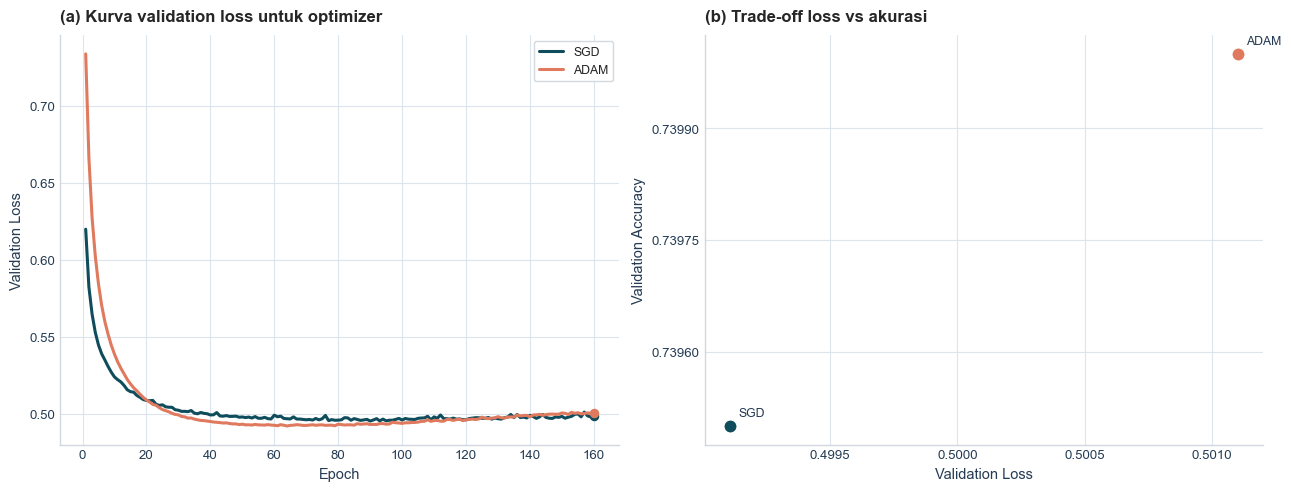

In [19]:
fig, axes = paper_axes(figsize=(12.8, 4.8))
plot_loss_panel(
    axes[0, 0],
    opt_results,
    label_fn=lambda r: r["optimizer"].upper(),
    title="(a) Kurva validation loss untuk optimizer",
)
plot_tradeoff_panel(
    axes[0, 1],
    opt_results,
    label_fn=lambda r: r["optimizer"].upper(),
    title="(b) Trade-off loss vs akurasi",
)
save_figure(fig, "optimizer_loss.png")



## 10) Perbandingan dengan sklearn MLP


In [20]:
model = nn.Sequential(
    [
        nn.Linear(X_train.shape[1], 32, init="he", seed=7),
        nn.Tanh(),
        nn.Linear(32, 32, init="he", seed=11),
        nn.Tanh(),
        nn.Linear(32, 32, init="he", seed=13),
        nn.Tanh(),
        nn.Linear(32, 1, init="he", seed=17),
    ]
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.03, l2_lambda=1e-4)
loader = DataLoader(
    ArrayDataset(X_train, y_train_col), batch_size=256, shuffle=True, seed=123
)

for epoch in range(160):
    for xb, yb in loader:
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

torch_prob = F.sigmoid(model(Tensor(X_val))).data.reshape(-1)
torch_pred = (torch_prob >= 0.5).astype(int)
torch_acc = accuracy_score(y_val, torch_pred)

auto_mlp = MLPClassifier(
    hidden_layer_sizes=(32, 32, 32),
    activation="tanh",
    solver="sgd",
    learning_rate_init=0.03,
    alpha=1e-4,
    max_iter=160,
    batch_size=256,
    shuffle=True,
    random_state=123,
)
auto_mlp.fit(X_train, y_train)
sk_pred = auto_mlp.predict(X_val)
sk_prob = auto_mlp.predict_proba(X_val)[:, 1]
sk_acc = accuracy_score(y_val, sk_pred)

disagreement = float(np.mean(torch_pred != sk_pred))

pd.DataFrame(
    [
        {
            "model": "torchlike",
            "val_acc": float(torch_acc),
            "val_log_loss": float(log_loss(y_val, torch_prob)),
        },
        {
            "model": "sklearn_mlp",
            "val_acc": float(sk_acc),
            "val_log_loss": float(log_loss(y_val, sk_prob)),
        },
    ]
)

/Users/ellipsis/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (160) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,val_acc,val_log_loss
0,torchlike,0.7465,0.496457
1,sklearn_mlp,0.6975,0.768242


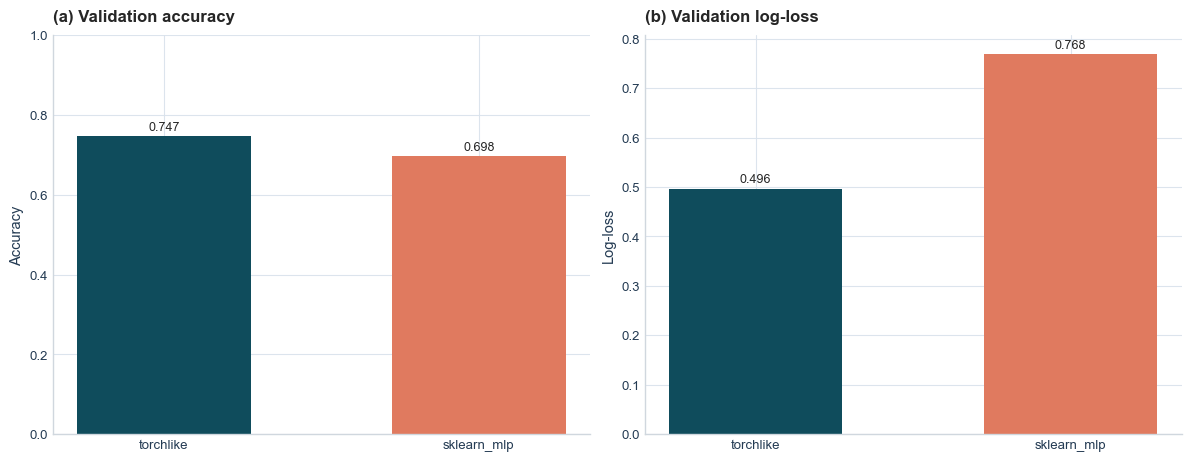

,model,val_acc,val_log_loss
0,torchlike,0.7465,0.496457
1,sklearn_mlp,0.6975,0.768242


In [21]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "torchlike",
            "val_acc": float(torch_acc),
            "val_log_loss": float(log_loss(y_val, torch_prob)),
        },
        {
            "model": "sklearn_mlp",
            "val_acc": float(sk_acc),
            "val_log_loss": float(log_loss(y_val, sk_prob)),
        },
    ]
)

fig, axes = paper_axes(figsize=(11.8, 4.5))
bar_colors = [PALETTE[0], PALETTE[1]]

axes[0, 0].bar(comparison_df["model"], comparison_df["val_acc"], width=0.55, color=bar_colors)
axes[0, 0].set_ylim(0.0, 1.0)
style_axis(axes[0, 0], title="(a) Validation accuracy", ylabel="Accuracy")
for i, value in enumerate(comparison_df["val_acc"]):
    axes[0, 0].text(i, value + 0.015, f"{value:.3f}", ha="center", fontsize=9)

axes[0, 1].bar(comparison_df["model"], comparison_df["val_log_loss"], width=0.55, color=bar_colors)
style_axis(axes[0, 1], title="(b) Validation log-loss", ylabel="Log-loss")
for i, value in enumerate(comparison_df["val_log_loss"]):
    axes[0, 1].text(i, value + 0.012, f"{value:.3f}", ha="center", fontsize=9)

save_figure(fig, "sklearn_comparison.png")
comparison_df



In [22]:
print("prediction disagreement rate (torchlike vs sklearn):", disagreement)

prediction disagreement rate (torchlike vs sklearn): 0.182
